## 1. Load the Dataset

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load the Dataset

In [69]:
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.data"

Column Name add

In [70]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
                'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

In [71]:
df = pd.read_csv(data_url, sep=r'\s+', names=column_names)

In [72]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [73]:
df.shape

(506, 14)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [75]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [76]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


## 2. Split the Dataset

In [77]:
from sklearn.model_selection import train_test_split

In [78]:
X = df.drop(columns=['MEDV'])
y = df['MEDV']

In [79]:
X.shape

(506, 13)

In [80]:
y.shape

(506,)

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [82]:
X_train.shape[0]

404

In [83]:
X_test.shape[0]

102

## 3. Train Models

LinearRegression

In [84]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [85]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

Ridge Regression (L2 regularization)

In [86]:
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)

Ridge(alpha=0.1)

Lasso Regression (L1 regularization)

In [87]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

Lasso(alpha=0.1)

## 4. Evaluate Models

In [88]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [89]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    return {
        'Model': name,
        'MSE'  : round(mse,  4),
        'RMSE' : round(rmse, 4),
        'R²'   : round(r2,   4),
        'MAE'  : round(mae,  4)
    }


In [90]:
results = [
    evaluate_model('Linear Regression', lr_model,    X_test, y_test),
    evaluate_model('Ridge Regression',  ridge_model, X_test, y_test),
    evaluate_model('Lasso Regression',  lasso_model, X_test, y_test),
]

In [91]:
results

[{'Model': 'Linear Regression',
  'MSE': 24.2911,
  'RMSE': np.float64(4.9286),
  'R²': 0.6688,
  'MAE': 3.1891},
 {'Model': 'Ridge Regression',
  'MSE': 24.301,
  'RMSE': np.float64(4.9296),
  'R²': 0.6686,
  'MAE': 3.1789},
 {'Model': 'Lasso Regression',
  'MSE': 25.1556,
  'RMSE': np.float64(5.0155),
  'R²': 0.657,
  'MAE': 3.1452}]

In [92]:
results_df = pd.DataFrame(results).set_index('Model')

In [93]:
results_df

,MSE,RMSE,R²,MAE
Model,,,,
Linear Regression,24.2911,4.9286,0.6688,3.1891
Ridge Regression,24.3010,4.9296,0.6686,3.1789
Lasso Regression,25.1556,5.0155,0.6570,3.1452


In [94]:
# Display the styled comparison table
print('=' * 60)
print('         MODEL COMPARISON — Housing Dataset')
print('=' * 60)
print(results_df.to_string())
print('=' * 60)
print('\nLower MSE / RMSE / MAE  →  better')
print('Higher R²               →  better (max = 1.0)')

         MODEL COMPARISON — Housing Dataset
                       MSE    RMSE      R²     MAE
Model                                             
Linear Regression  24.2911  4.9286  0.6688  3.1891
Ridge Regression   24.3010  4.9296  0.6686  3.1789
Lasso Regression   25.1556  5.0155  0.6570  3.1452

Lower MSE / RMSE / MAE  →  better
Higher R²               →  better (max = 1.0)


## Visualizations

In [95]:
# Styled display (works great in Colab/Jupyter)
results_df.style \
    .highlight_min(subset=['MSE', 'RMSE', 'MAE'], color='lightgreen') \
    .highlight_max(subset=['R²'],                  color='lightgreen') \
    .format('{:.4f}') \
    .set_caption('📊 Model Comparison (green = best value)')

,MSE,RMSE,R²,MAE
Model,,,,
Linear Regression,24.2911,4.9286,0.6688,3.1891
Ridge Regression,24.3010,4.9296,0.6686,3.1789
Lasso Regression,25.1556,5.0155,0.6570,3.1452


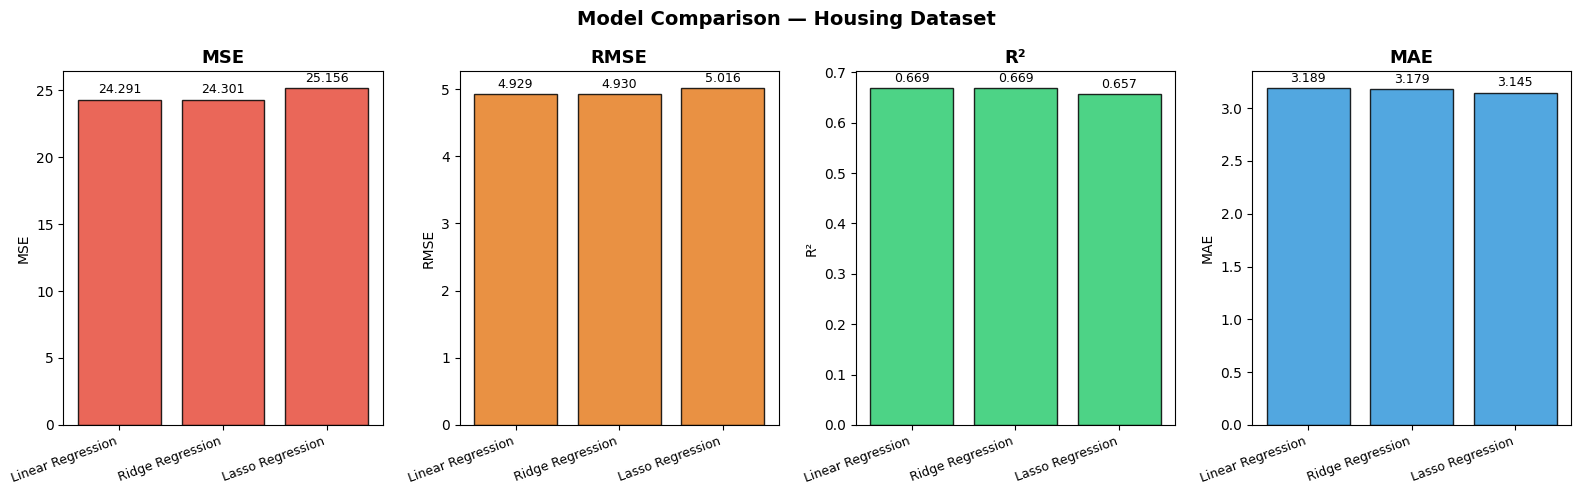

📊 Chart saved as model_comparison.png


In [96]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Model Comparison — Housing Dataset', fontsize=14, fontweight='bold')

metrics = ['MSE', 'RMSE', 'R²', 'MAE']
colors  = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']

for ax, metric, color in zip(axes, metrics, colors):
    values = results_df[metric].values
    bars   = ax.bar(results_df.index, values, color=color, alpha=0.85, edgecolor='black')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(results_df.index))) # Set ticks explicitly
    ax.set_xticklabels(results_df.index, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(metric)
    # Annotate each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved as model_comparison.png')

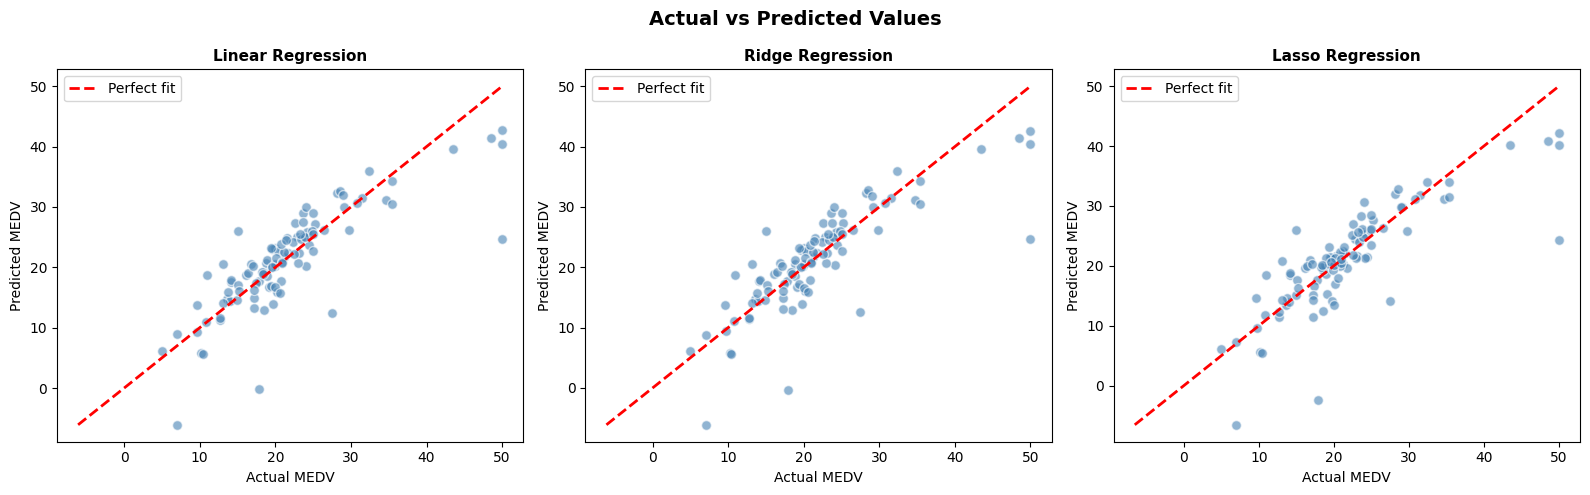

In [97]:
# Actual vs Predicted scatter plots for all three models
models     = [lr_model, ridge_model, lasso_model]
model_names = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Actual vs Predicted Values', fontsize=14, fontweight='bold')

for ax, model, name in zip(axes, models, model_names):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=50)
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect fit')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual MEDV')
    ax.set_ylabel('Predicted MEDV')
    ax.legend()

plt.tight_layout()
plt.show()

In [98]:
# Compare feature coefficients across models
coef_df = pd.DataFrame({
    'Feature'           : X.columns,
    'Linear Regression' : lr_model.coef_,
    'Ridge Regression'  : ridge_model.coef_,
    'Lasso Regression'  : lasso_model.coef_,
})
coef_df = coef_df.set_index('Feature')
print('Feature Coefficients:')
print(coef_df.round(4).to_string())
print('\n(Lasso coefficients set to 0 indicate feature elimination)')

Feature Coefficients:
         Linear Regression  Ridge Regression  Lasso Regression
Feature                                                       
CRIM               -0.1131           -0.1124           -0.1042
ZN                  0.0301            0.0305            0.0349
INDUS               0.0404            0.0349           -0.0168
CHAS                2.7844            2.7503            0.9200
NOX               -17.2026          -15.9245           -0.0000
RM                  4.4388            4.4458            4.3117
AGE                -0.0063           -0.0073           -0.0151
DIS                -1.4479           -1.4296           -1.1515
RAD                 0.2624            0.2600            0.2392
TAX                -0.0106           -0.0108           -0.0130
PTRATIO            -0.9155           -0.9008           -0.7322
B                   0.0124            0.0124            0.0131
LSTAT              -0.5086           -0.5109           -0.5647

(Lasso coefficients set to 0 ind

### Key observations:
- A **higher R²** (closer to 1.0) means the model explains more variance in the target variable.
- **Lower MSE / RMSE / MAE** means the model's predictions are closer to the true values.
- Ridge and Lasso help prevent overfitting through regularization, often giving similar or better test performance than plain Linear Regression.
- Lasso can completely zero out less important features, acting as automatic feature selection.

## Accuracy

In [99]:
def regression_accuracy(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = r2_score(y_test, y_pred) * 100
    return {"Model": name, "Accuracy (%)": round(accuracy, 2)}

In [100]:
results = [
    regression_accuracy('Linear Regression', lr_model, X_test, y_test),
    regression_accuracy('Ridge Regression', ridge_model, X_test, y_test),
    regression_accuracy('Lasso Regression', lasso_model, X_test, y_test),
]

In [103]:
results_df = pd.DataFrame(results).set_index('Model')

In [102]:
results_df

,Accuracy (%)
Model,
Linear Regression,66.88
Ridge Regression,66.86
Lasso Regression,65.70


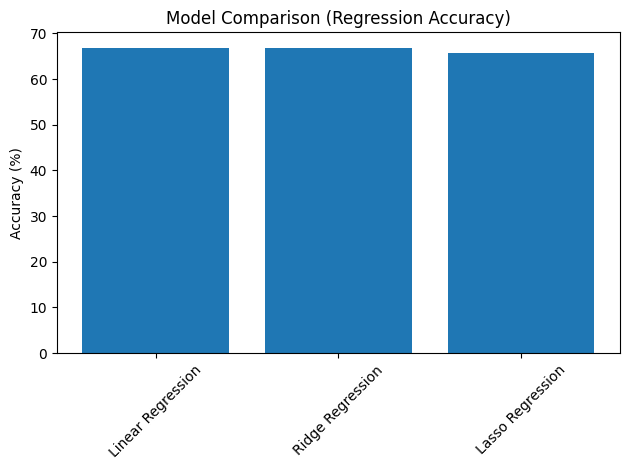

In [104]:
import matplotlib.pyplot as plt

names = results_df.index
scores = results_df["Accuracy (%)"]

plt.figure()
plt.bar(names, scores)
plt.xticks(rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison (Regression Accuracy)")
plt.tight_layout()
plt.show()